# Model Reporting Visualizations

Predicted vs actual scatter plots for all 5 models, and SHAP violin plots (feature value vs SHAP value) for the tree-based models (Random Forest, XGBoost, CatBoost).

Run this notebook via `kedro jupyter notebook` (or `kedro jupyter lab`) from the project root so the `catalog` variable is available.

In [14]:
import matplotlib.pyplot as plt
import shap

## Predicted vs Actual

In [15]:
%reload_ext kedro.ipython

[08/17/26 05:49:44] INFO     Registered line magic '%reload_kedro'                                   ]8;id=14575607;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=14575608;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py#67\67]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=14575613;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=14575614;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py#69\69]8;;\

                    INFO     Resolved project path as:                                              ]8;id=14575619;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=14575620;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py#193\193]8;;\
                             /workspaces/dh-food-delivery-time/model_pipeline.                                     
                             To set a different path, run '%reload_kedro <project_root>'                           

                    INFO     No typed parameter requirements found, returning original   ]8;id=14575625;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/validation/parameter_validator.py\parameter_validator.py]8;;\:]8;id=14575626;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/validation/parameter_validator.py#124\124]8;;\
                             parameters                                                                            

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=14575631;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro_telemetry/plugin.py\plugin.py]8;;\:]8;id=14575632;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro_telemetry/plugin.py#273\273]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

                    INFO     Kedro project model_pipeline                                           ]8;id=14575637;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=14575638;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py#159\159]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=14575643;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=14575644;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py#160\160]8;;\
                             'pipelines'                                                                           

                    INFO     Loading data from modout_prediction_linear_regression             ]8;id=14575649;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=14575650;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\
                             (CSVDataset)...                                                                       

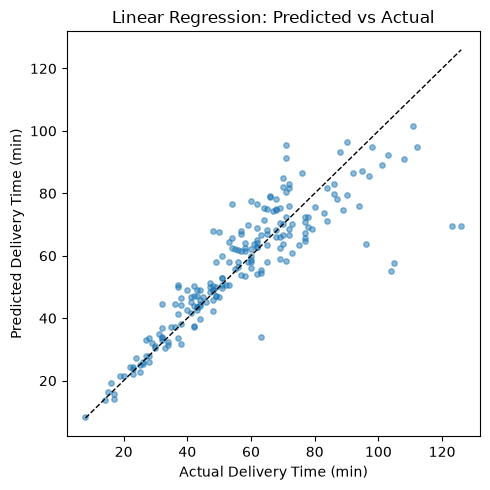

[08/17/26 05:49:45] INFO     Loading data from modout_prediction_lasso_regression              ]8;id=14575655;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=14575656;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\
                             (CSVDataset)...                                                                       

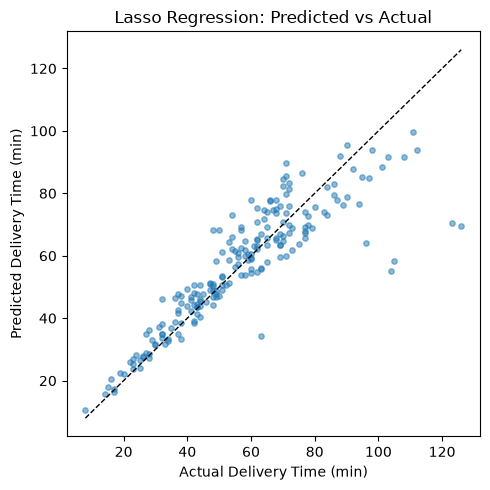

                    INFO     Loading data from modout_prediction_random_forest (CSVDataset)... ]8;id=14575661;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=14575662;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

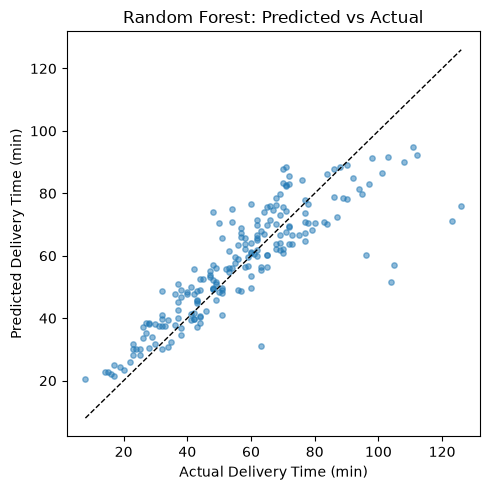

                    INFO     Loading data from modout_prediction_xgboost (CSVDataset)...       ]8;id=14575667;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=14575668;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

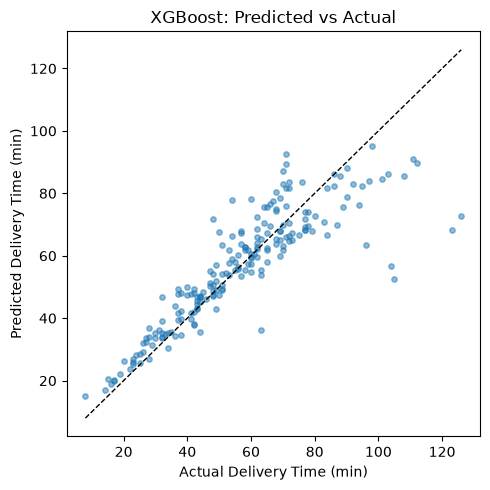

                    INFO     Loading data from modout_prediction_catboost (CSVDataset)...      ]8;id=14575673;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=14575674;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

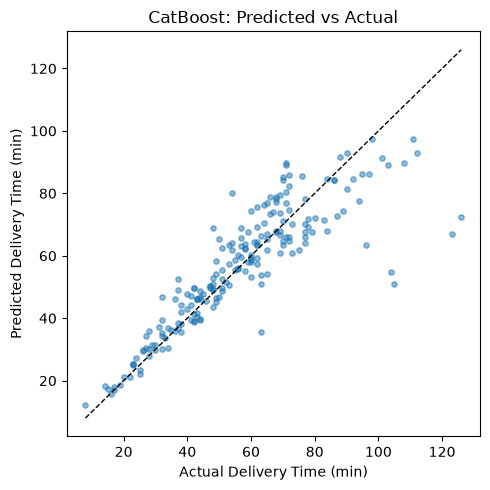

In [16]:
prediction_tables = {
    "Linear Regression": "modout_prediction_linear_regression",
    "Lasso Regression": "modout_prediction_lasso_regression",
    "Random Forest": "modout_prediction_random_forest",
    "XGBoost": "modout_prediction_xgboost",
    "CatBoost": "modout_prediction_catboost",
}

for model_name, dataset_name in prediction_tables.items():
    predictions = catalog.load(dataset_name)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(predictions["y_true"], predictions["y_pred"], alpha=0.5, s=15)

    lims = [
        min(predictions["y_true"].min(), predictions["y_pred"].min()),
        max(predictions["y_true"].max(), predictions["y_pred"].max()),
    ]
    ax.plot(lims, lims, color="black", linestyle="--", linewidth=1)

    ax.set_xlabel("Actual Delivery Time (min)")
    ax.set_ylabel("Predicted Delivery Time (min)")
    ax.set_title(f"{model_name}: Predicted vs Actual")
    fig.tight_layout()
    plt.show()

## SHAP Violin Plots (Tree-Based Models)

Each violin shows the distribution of each feature's SHAP contribution to the predicted delivery time (in minutes), colored by that feature's own value — showing how the feature's value correlates with its effect on the prediction.

[08/17/26 05:52:08] INFO     Loading data from model_random_forest (PickleDataset)...          ]8;id=14575739;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=14575740;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from modin_test_encoded_categorical (CSVDataset)...  ]8;id=14575745;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=14575746;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

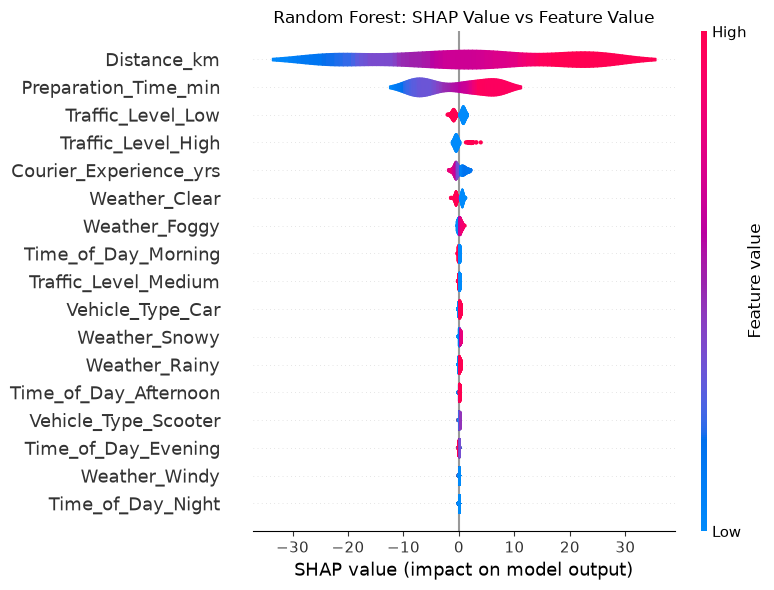

In [20]:
tree_models = {
    "Random Forest": ("model_random_forest", "modin_test_encoded_categorical"),
}

for model_name, (model_dataset, features_dataset) in tree_models.items():
    model = catalog.load(model_dataset)
    X_test = catalog.load(features_dataset)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    shap.summary_plot(
        shap_values, X_test, plot_type="violin", plot_size=(8, 6), show=False
    )
    plt.title(f"{model_name}: SHAP Value vs Feature Value")
    plt.tight_layout()
    plt.show()

## SHAP Value by Category (XGBoost, CatBoost)

Uses the pipeline's precomputed `shap_by_category_xgboost`/`shap_by_category_catboost` tables (mean SHAP value grouped by each observed category value) instead of recomputing SHAP here. This is a better fit for nominal categorical features than the violin plot above, whose color gradient is built for continuous values. Random Forest has no equivalent table -- its categorical features are already split into one-hot dummy columns, so it keeps the violin plot only.

[08/17/26 05:51:55] INFO     Loading data from shap_by_category_xgboost (CSVDataset)...        ]8;id=14575727;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=14575728;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

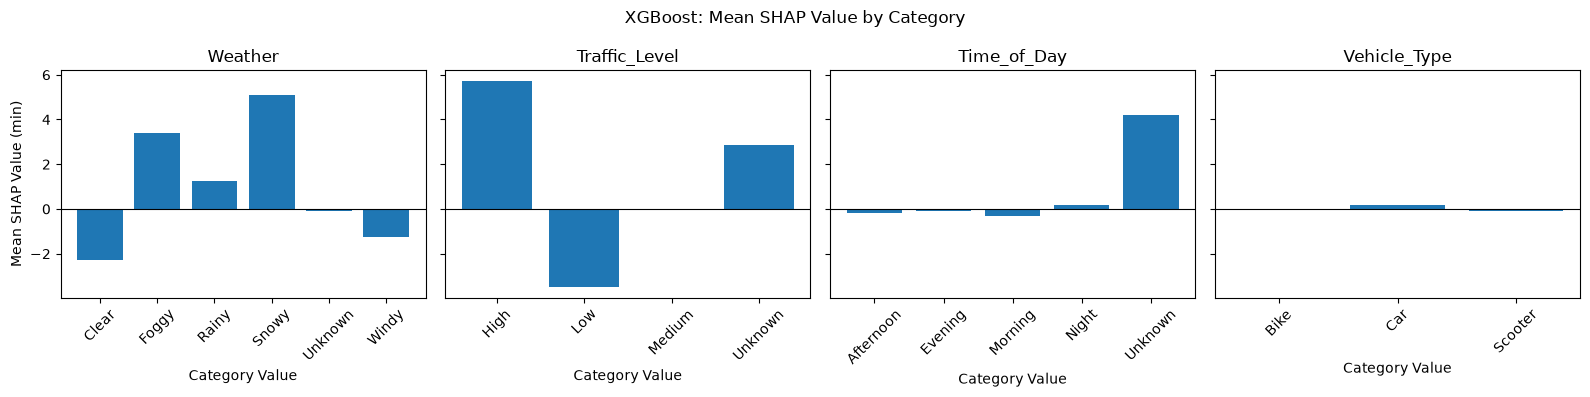

                    INFO     Loading data from shap_by_category_catboost (CSVDataset)...       ]8;id=14575733;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=14575734;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

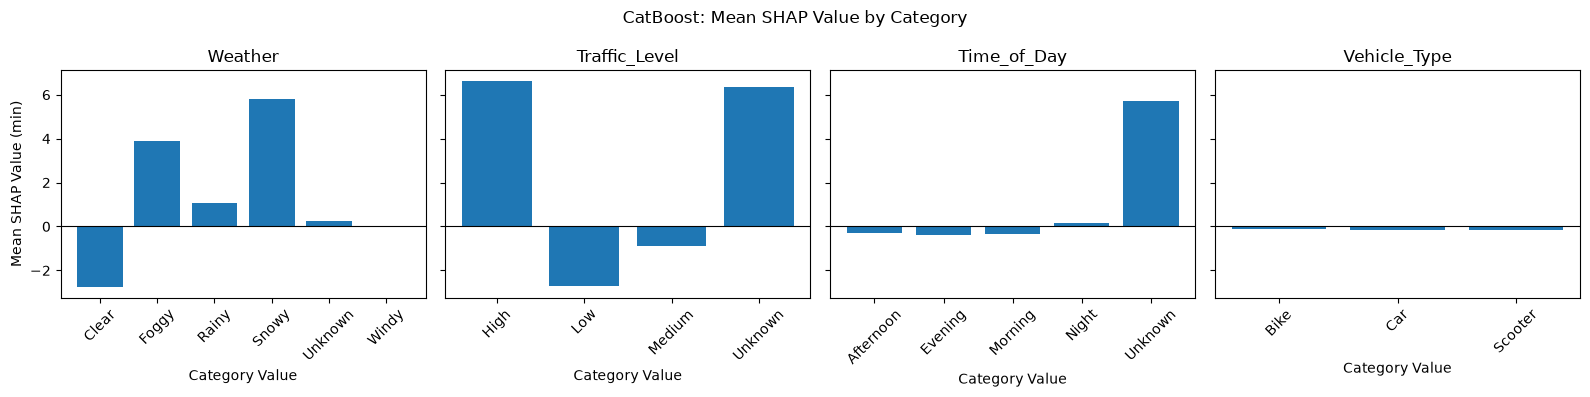

In [19]:
category_shap_tables = {
    "XGBoost": "shap_by_category_xgboost",
    "CatBoost": "shap_by_category_catboost",
}

for model_name, dataset_name in category_shap_tables.items():
    shap_by_category = catalog.load(dataset_name)
    features = shap_by_category["Feature"].unique()

    fig, axes = plt.subplots(1, len(features), figsize=(4 * len(features), 4), sharey=True)
    if len(features) == 1:
        axes = [axes]

    for ax, feature in zip(axes, features):
        feature_data = shap_by_category[shap_by_category["Feature"] == feature]
        ax.bar(feature_data["Category Value"], feature_data["Mean SHAP Value"])
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(feature)
        ax.set_xlabel("Category Value")
        ax.tick_params(axis="x", rotation=45)

    axes[0].set_ylabel("Mean SHAP Value (min)")
    fig.suptitle(f"{model_name}: Mean SHAP Value by Category")
    fig.tight_layout()
    plt.show()